## Pumpkin Varieties and Color

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

Let's look at the relationship between color and variety

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

full_pumpkins = pd.read_csv('../data/US-pumpkins.csv')

full_pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [ ]:
# View total number of missing values in each column
full_pumpkins.isnull().sum()




City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [ ]:
full_pumpkins.columns[full_pumpkins.isnull().all()]



Index(['Grade', 'Environment', 'Quality', 'Condition', 'Appearance', 'Storage',
       'Crop', 'Trans Mode', 'Unnamed: 24'],
      dtype='object')

In [ ]:

full_pumpkins['Date'] = pd.to_datetime(full_pumpkins['Date'], errors='coerce')
full_pumpkins['Year'] = full_pumpkins['Date'].dt.year
full_pumpkins['Month'] = full_pumpkins['Date'].dt.month
full_pumpkins['Day'] = full_pumpkins['Date'].dt.day

full_pumpkins.drop(columns=['Date'], inplace=True)


full_pumpkins.head()










C:\Users\Nkansah\AppData\Local\Temp\ipykernel_11860\925248656.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_pumpkins['Date'] = pd.to_datetime(full_pumpkins['Date'], errors='coerce')


,City Name,Type,Package,Variety,Sub Variety,Grade,Low Price,High Price,Mostly Low,Mostly High,...,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25,Year,Month,Day
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,270.0,280.0,270.0,280.0,...,NaN,NaN,NaN,E,NaN,NaN,NaN,2017,4,29
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,270.0,280.0,270.0,280.0,...,NaN,NaN,NaN,E,NaN,NaN,NaN,2017,5,6
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,160.0,160.0,160.0,160.0,...,NaN,NaN,NaN,N,NaN,NaN,NaN,2016,9,24
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,160.0,160.0,160.0,160.0,...,NaN,NaN,NaN,N,NaN,NaN,NaN,2016,9,24
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,90.0,100.0,90.0,100.0,...,NaN,NaN,NaN,N,NaN,NaN,NaN,2016,11,5


In [ ]:
# View total number of missing values in each column
full_pumpkins.isnull().sum()


City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
Year                  0
Month                 0
Day                   0
dtype: int64

In [ ]:
columns_to_select = ['City Name',  'Package', 'Variety',  'Low Price', 'High Price', 'Mostly Low', 'Mostly High', 'Origin',  'Item Size', 'Color', 'Repack' ,'Year', 'Month', 'Day']
pumpkins = full_pumpkins.loc[:, columns_to_select]

pumpkins.dropna(inplace = True)

In [ ]:
pumpkins.head()

,City Name,Package,Variety,Low Price,High Price,Mostly Low,Mostly High,Origin,Item Size,Color,Repack,Year,Month,Day
2,BALTIMORE,24 inch bins,HOWDEN TYPE,160.0,160.0,160.0,160.0,DELAWARE,med,ORANGE,N,2016,9,24
3,BALTIMORE,24 inch bins,HOWDEN TYPE,160.0,160.0,160.0,160.0,VIRGINIA,med,ORANGE,N,2016,9,24
4,BALTIMORE,24 inch bins,HOWDEN TYPE,90.0,100.0,90.0,100.0,MARYLAND,lge,ORANGE,N,2016,11,5
5,BALTIMORE,24 inch bins,HOWDEN TYPE,90.0,100.0,90.0,100.0,MARYLAND,lge,ORANGE,N,2016,11,12
6,BALTIMORE,36 inch bins,HOWDEN TYPE,160.0,170.0,160.0,170.0,MARYLAND,med,ORANGE,N,2016,9,24


In [ ]:
pumpkins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 946 entries, 2 to 1624
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City Name    946 non-null    object 
 1   Package      946 non-null    object 
 2   Variety      946 non-null    object 
 3   Low Price    946 non-null    float64
 4   High Price   946 non-null    float64
 5   Mostly Low   946 non-null    float64
 6   Mostly High  946 non-null    float64
 7   Origin       946 non-null    object 
 8   Item Size    946 non-null    object 
 9   Color        946 non-null    object 
 10  Repack       946 non-null    object 
 11  Year         946 non-null    int32  
 12  Month        946 non-null    int32  
 13  Day          946 non-null    int32  
dtypes: float64(4), int32(3), object(7)
memory usage: 99.8+ KB


In [ ]:
pumpkins['Color'].unique()


array(['ORANGE', 'WHITE'], dtype=object)

### Visualization - Categorical plot

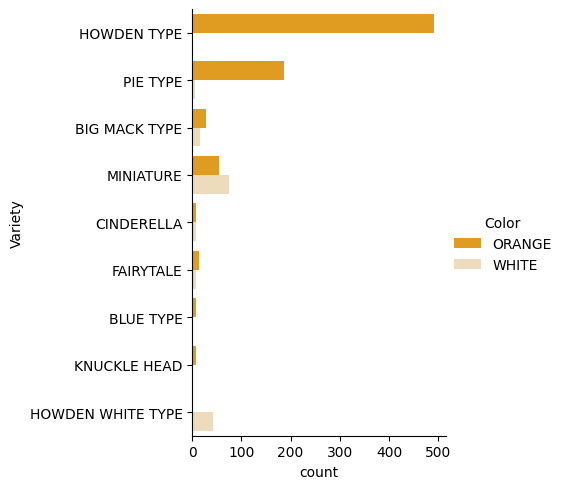

In [ ]:
palette = {
    'ORANGE' : 'orange',
    'WHITE' : 'wheat',
    
}

sns.catplot(
    data=pumpkins, y="Variety", hue="Color", kind="count",
    palette=palette,
)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['City Name',   'Package', 'Variety',    'Origin', 'Repack']
categorical_encoder = OneHotEncoder(sparse_output=False)

In [ ]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[
    ('ord', ordinal_encoder, ordinal_features), # Apply ordinal encoding
    ('cat', categorical_encoder, categorical_features) # Apply one-hot encoding
])

ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(pumpkins)

In [ ]:
from sklearn.preprocessing import LabelEncoder
    
label_encoder = LabelEncoder()

encoded_label = label_encoder.fit_transform(pumpkins['Color'])

In [ ]:
encoded_pumpkins = encoded_features.assign(Color=encoded_label)

In [ ]:
encoded_pumpkins.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA,cat__Repack_N,Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


C:\Users\Nkansah\AppData\Local\Temp\ipykernel_11860\2518198620.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


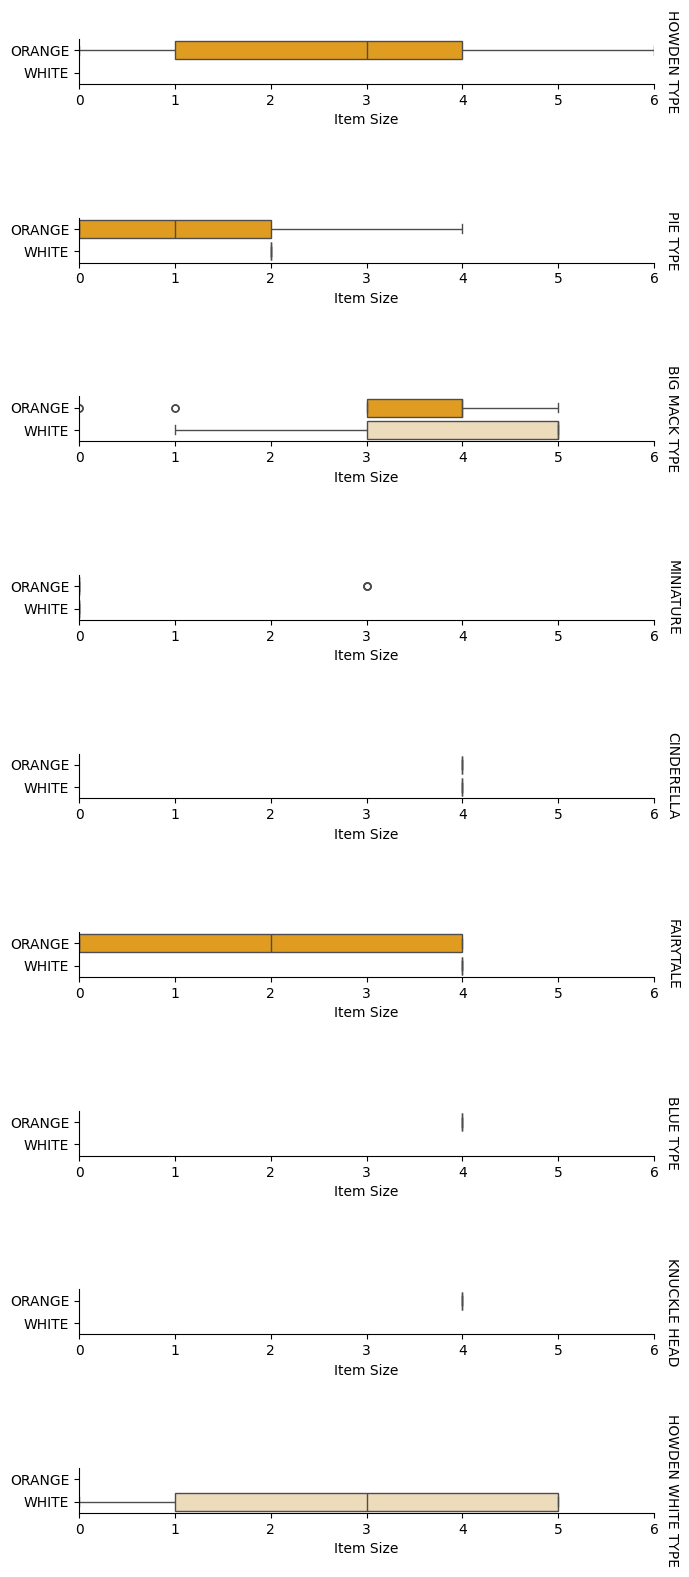

In [ ]:
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
    
    }
pumpkins['Item Size'] = encoded_pumpkins['ord__Item Size']

g = sns.catplot(
        data=pumpkins,
        x="Item Size", y="Color", row='Variety',
        kind="box", orient="h",
        sharex=False, margin_titles=True,
        height=1.8, aspect=4, palette=palette,
    )
g.set(xlabel="Item Size", ylabel="").set(xlim=(0,6))
g.set_titles(row_template="{row_name}")


C:\Users\Nkansah\AppData\Local\Temp\ipykernel_11860\2537854091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Color", y="ord__Item Size", data=encoded_pumpkins, palette=palette)
c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 61.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Color', ylabel='ord__Item Size'>

c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 78.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 37.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


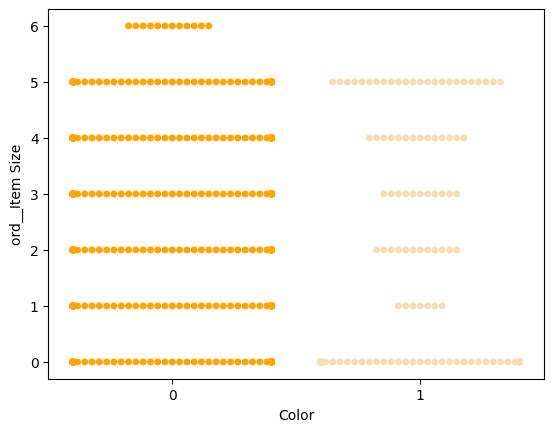

In [ ]:
palette = {
	'0': 'orange',
	'1': 'wheat'
}
encoded_pumpkins['Color'] = encoded_pumpkins['Color'].astype(str)
sns.swarmplot(x="Color", y="ord__Item Size", data=encoded_pumpkins, palette=palette)

In [ ]:
from sklearn.model_selection import train_test_split

X = encoded_pumpkins[encoded_pumpkins.columns.difference(['Color'])]
y = encoded_pumpkins['Color']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [ ]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)

print(classification_report(y_test, pred))
print('Predicted labels: ', pred)
print('F1-score: ', f1_score(y_test.astype(int), pred.astype(int)))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       170
           1       0.88      0.75      0.81        20

    accuracy                           0.96       190
   macro avg       0.93      0.87      0.90       190
weighted avg       0.96      0.96      0.96       190

Predicted labels:  ['1' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '0' '0'
 '0' '1' '0' '0' '1' '0' '1' '0' '0' '0' '0' '0' '0' '0' '1' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '1' '1' '0' '0' '0' '0' '0' '0' '1' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '1' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '1' '0' '0' '0' '0' '1' '0' '0' '0' '0' '0' '0'
 '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '0' '

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred)

array([[168,   2],
       [  5,  15]])

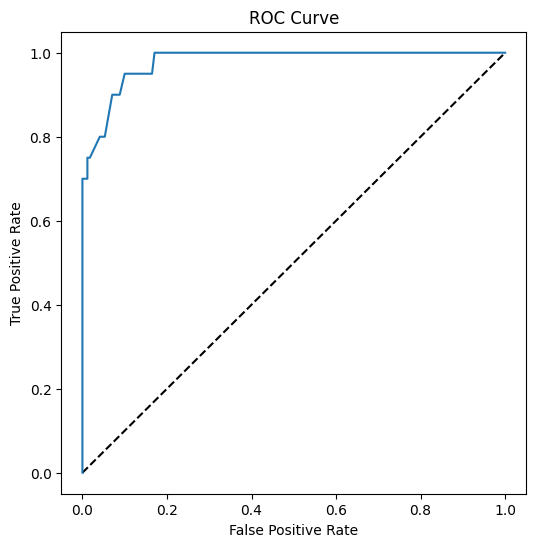

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt
%matplotlib inline

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test.astype(int), y_scores[:,1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
auc = roc_auc_score(y_test.astype(int),y_scores[:,1])
print(auc)

0.9786764705882353


In [ ]:
# import pickle
# model_filename = 'pumpkin_model.pkl'
# pickle.dump(model, open(model_filename,'wb'))

# model = pickle.load(open('pumpkin_model.pkl','rb'))

In [ ]:
print(model.predict([[1,1,1]]))